# NBA Offensive Archetype Clustering

**Research question:** Can NBA players be grouped into offensive archetypes based solely on their shot profile data — without using player names, positions, or reputation — and do the resulting clusters resemble how analysts already describe players (rim-running centers, three-point specialists, shot creators, mid-range scorers, balanced offensive players)?

**Approach:** Unsupervised clustering (e.g. K-Means, hierarchical, GMM) applied to shot-profile features engineered from NBA shot location / play-by-play data.

**Notebook sections**
1. Setup & imports
2. Data collection
3. Data cleaning
4. Feature engineering
5. Preprocessing (scaling)
6. Choosing the number of clusters
7. Clustering
8. Cluster evaluation & visualization
9. Comparing clusters to known archetypes
10. Limitations & next steps


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

pd.set_option("display.max_columns", 50)


Matplotlib is building the font cache; this may take a moment.


## 2. Data Collection

**Goal:** end up with one row per player (per season) containing shot location counts/efficiency and shot-creation info.

**Candidate real data sources to wire in later:**
- `nba_api` (`nba_api.stats.endpoints.shotchartdetail`, `leaguedashplayershotlocations`, `playerdashptshots`) for shot zone frequency/efficiency and shot-creation (assisted vs. unassisted) splits.
- NBA.com stats pages / Basketball-Reference for season-level shooting splits if the API is unavailable.
- A locally saved shot-log CSV export, if you've already pulled data elsewhere.

For now, the cell below generates a **synthetic** player-shot-profile dataset so the rest of the notebook (feature engineering → clustering → evaluation) can be built and tested before real data is wired in. Replace `load_shot_data()` with a real loader when ready — keep the same output schema described below and everything downstream should still work.

**Target schema (`raw_df`), one row per player:**
- `player_id`, `player_name` (kept aside, not used as clustering features)
- `fga_rim`, `fga_paint_non_ra`, `fga_midrange`, `fga_corner3`, `fga_above_break3` — attempt counts by zone
- `fgm_rim`, `fgm_paint_non_ra`, `fgm_midrange`, `fgm_corner3`, `fgm_above_break3` — makes by zone
- `assisted_fgm`, `unassisted_fgm` — makes by assist status
- `total_fga` — total field goal attempts (for filtering low-volume players)


In [2]:
def load_shot_data(n_players: int = 200, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """
    Placeholder data loader.

    Replace the body of this function with a real data pull (e.g. nba_api) that
    returns a DataFrame matching the schema described above. For now it simulates
    a handful of loose "archetypes" so the clustering pipeline has believable
    structure to recover.
    """
    rng = np.random.default_rng(random_state)

    archetypes = {
        "rim_runner":        dict(rim=.55, paint=.20, mid=.15, corner3=.05, above3=.05, assisted=.85),
        "three_and_d":       dict(rim=.15, paint=.10, mid=.10, corner3=.35, above3=.30, assisted=.80),
        "shot_creator":      dict(rim=.25, paint=.15, mid=.20, corner3=.10, above3=.30, assisted=.25),
        "midrange_scorer":   dict(rim=.15, paint=.15, mid=.45, corner3=.10, above3=.15, assisted=.55),
        "balanced_wing":     dict(rim=.25, paint=.15, mid=.20, corner3=.15, above3=.25, assisted=.60),
    }

    rows = []
    names = list(archetypes.keys())
    for i in range(n_players):
        arche = names[i % len(names)]
        base = archetypes[arche]

        total_fga = int(rng.normal(650, 150))
        total_fga = max(total_fga, 150)

        # add noise to zone shares, then renormalize
        shares = np.array([base["rim"], base["paint"], base["mid"], base["corner3"], base["above3"]])
        shares = np.clip(shares + rng.normal(0, 0.04, size=5), 0.01, None)
        shares = shares / shares.sum()

        fga_rim, fga_paint, fga_mid, fga_corner3, fga_above3 = (shares * total_fga).round().astype(int)

        # zone-specific FG% (rough league-average-ish anchors + noise)
        fg_pct = {
            "rim":     np.clip(rng.normal(0.63, 0.06), 0.35, 0.85),
            "paint":   np.clip(rng.normal(0.42, 0.06), 0.20, 0.65),
            "mid":     np.clip(rng.normal(0.41, 0.05), 0.20, 0.60),
            "corner3": np.clip(rng.normal(0.38, 0.05), 0.15, 0.55),
            "above3":  np.clip(rng.normal(0.35, 0.05), 0.15, 0.50),
        }

        fgm_rim = int(round(fga_rim * fg_pct["rim"]))
        fgm_paint = int(round(fga_paint * fg_pct["paint"]))
        fgm_mid = int(round(fga_mid * fg_pct["mid"]))
        fgm_corner3 = int(round(fga_corner3 * fg_pct["corner3"]))
        fgm_above3 = int(round(fga_above3 * fg_pct["above3"]))

        total_fgm = fgm_rim + fgm_paint + fgm_mid + fgm_corner3 + fgm_above3
        assisted_rate = np.clip(base["assisted"] + rng.normal(0, 0.05), 0.05, 0.98)
        assisted_fgm = int(round(total_fgm * assisted_rate))
        unassisted_fgm = total_fgm - assisted_fgm

        rows.append(dict(
            player_id=i,
            player_name=f"Player_{i:03d}",
            true_archetype_for_reference_only=arche,  # NOTE: keep this OUT of clustering features
            fga_rim=fga_rim, fga_paint_non_ra=fga_paint, fga_midrange=fga_mid,
            fga_corner3=fga_corner3, fga_above_break3=fga_above3,
            fgm_rim=fgm_rim, fgm_paint_non_ra=fgm_paint, fgm_midrange=fgm_mid,
            fgm_corner3=fgm_corner3, fgm_above_break3=fgm_above3,
            assisted_fgm=assisted_fgm, unassisted_fgm=unassisted_fgm,
            total_fga=fga_rim + fga_paint + fga_mid + fga_corner3 + fga_above3,
        ))

    return pd.DataFrame(rows)


raw_df = load_shot_data()
raw_df.head()


,player_id,player_name,true_archetype_for_reference_only,fga_rim,fga_paint_non_ra,fga_midrange,fga_corner3,fga_above_break3,fgm_rim,fgm_paint_non_ra,fgm_midrange,fgm_corner3,fgm_above_break3,assisted_fgm,unassisted_fgm,total_fga
0,0,Player_000,rim_runner,373,169,138,7,7,238,68,56,2,3,326,41,694
1,1,Player_001,three_and_d,128,78,43,239,171,87,33,17,83,70,230,60,659
2,2,Player_002,shot_creator,131,95,119,65,176,99,38,46,22,67,83,189,586
3,3,Player_003,midrange_scorer,73,73,298,81,107,43,32,124,32,42,153,120,632
4,4,Player_004,balanced_wing,196,125,175,71,184,118,48,69,32,56,209,114,751


## 3. Data Cleaning

Basic sanity checks and filtering. A common real-world choice: drop very low-volume shooters (small sample sizes make zone efficiency noisy) — e.g. require a minimum number of total field goal attempts for the season.


In [3]:
MIN_FGA = 200  # adjust once real data / sample sizes are known

df = raw_df.copy()
print("Before filtering:", df.shape)

df = df[df["total_fga"] >= MIN_FGA].reset_index(drop=True)
print("After filtering (min FGA):", df.shape)

df.isna().sum()


Before filtering: (200, 16)
After filtering (min FGA): (200, 16)


player_id                            0
player_name                          0
true_archetype_for_reference_only    0
fga_rim                              0
fga_paint_non_ra                     0
fga_midrange                         0
fga_corner3                          0
fga_above_break3                     0
fgm_rim                              0
fgm_paint_non_ra                     0
fgm_midrange                         0
fgm_corner3                          0
fgm_above_break3                     0
assisted_fgm                         0
unassisted_fgm                       0
total_fga                            0
dtype: int64

## 4. Feature Engineering

Convert raw counts into **rate-based** features so players are compared on shot *profile* (shape of their shot selection and efficiency) rather than raw volume. Planned features:

- Zone frequency shares: `pct_fga_rim`, `pct_fga_paint`, `pct_fga_midrange`, `pct_fga_corner3`, `pct_fga_above3`
- Zone efficiency: `efg_rim`, `efg_paint`, `efg_midrange`, `efg_corner3`, `efg_above3` (corner/above-break 3s weighted for the extra point)
- Aggregate shot-selection metrics: `pct_rim_plus_three` (rim + all threes, i.e. "shot quality" attempts), `three_point_rate`, `midrange_rate`
- Shot creation: `pct_assisted`, `pct_unassisted`

Feel free to expand this feature set once real tracking data (e.g. touch time, dribbles per touch, contested vs. open shots) is available.


In [4]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    zones = ["rim", "paint_non_ra", "midrange", "corner3", "above_break3"]

    # Frequency shares
    for z in zones:
        out[f"pct_fga_{z}"] = out[f"fga_{z}"] / out["total_fga"]

    # Zone efficiency (raw FG%, treat separately from value; simple version for the scaffold)
    for z in zones:
        with np.errstate(divide="ignore", invalid="ignore"):
            out[f"fgpct_{z}"] = np.where(out[f"fga_{z}"] > 0, out[f"fgm_{z}"] / out[f"fga_{z}"], np.nan)

    # Aggregate shot-selection metrics
    out["three_point_rate"] = (out["fga_corner3"] + out["fga_above_break3"]) / out["total_fga"]
    out["rim_plus_three_rate"] = (out["fga_rim"] + out["fga_corner3"] + out["fga_above_break3"]) / out["total_fga"]
    out["midrange_rate"] = out["fga_midrange"] / out["total_fga"]

    # Shot creation
    total_fgm = out[[f"fgm_{z}" for z in zones]].sum(axis=1)
    out["pct_assisted"] = out["assisted_fgm"] / total_fgm.replace(0, np.nan)
    out["pct_unassisted"] = out["unassisted_fgm"] / total_fgm.replace(0, np.nan)

    return out


features_df = engineer_features(df)

# Fill any NaN zone-efficiency values (e.g. zero attempts in a zone) with the column median
# as a simple placeholder strategy — revisit once real data volumes are known.
fgpct_cols = [c for c in features_df.columns if c.startswith("fgpct_")]
features_df[fgpct_cols] = features_df[fgpct_cols].fillna(features_df[fgpct_cols].median())

features_df[["player_name"] + fgpct_cols + ["three_point_rate", "rim_plus_three_rate", "pct_assisted"]].head()


,player_name,fgpct_rim,fgpct_paint_non_ra,fgpct_midrange,fgpct_corner3,fgpct_above_break3,three_point_rate,rim_plus_three_rate,pct_assisted
0,Player_000,0.638070,0.402367,0.405797,0.285714,0.428571,0.020173,0.557637,0.888283
1,Player_001,0.679688,0.423077,0.395349,0.347280,0.409357,0.622155,0.816388,0.793103
2,Player_002,0.755725,0.400000,0.386555,0.338462,0.380682,0.411263,0.634812,0.305147
3,Player_003,0.589041,0.438356,0.416107,0.395062,0.392523,0.297468,0.412975,0.560440
4,Player_004,0.602041,0.384000,0.394286,0.450704,0.304348,0.339547,0.600533,0.647059


## 5. Preprocessing

Select the feature columns that will actually go into clustering (exclude IDs, names, and — importantly — any ground-truth/reference labels), then standardize since K-Means and related methods are sensitive to feature scale.


In [5]:
FEATURE_COLS = [
    "pct_fga_rim", "pct_fga_paint_non_ra", "pct_fga_midrange", "pct_fga_corner3", "pct_fga_above_break3",
    "fgpct_rim", "fgpct_paint_non_ra", "fgpct_midrange", "fgpct_corner3", "fgpct_above_break3",
    "three_point_rate", "rim_plus_three_rate", "midrange_rate",
    "pct_assisted", "pct_unassisted",
]

X = features_df[FEATURE_COLS].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=features_df.index)
X_scaled_df.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
pct_fga_rim,-1.598721e-16,1.002509,-1.266325,2.499264
pct_fga_paint_non_ra,9.325873e-17,1.002509,-2.603655,2.583219
pct_fga_midrange,-1.332268e-17,1.002509,-1.652703,2.363729
pct_fga_corner3,-1.776357e-16,1.002509,-1.222116,2.355293
pct_fga_above_break3,-1.332268e-16,1.002509,-1.924193,1.999264
fgpct_rim,3.252953e-16,1.002509,-2.291643,3.021550
fgpct_paint_non_ra,3.885781e-16,1.002509,-2.987080,3.030269
fgpct_midrange,1.211253e-15,1.002509,-2.296614,2.911838
fgpct_corner3,4.973799e-16,1.002509,-3.170112,2.591964
fgpct_above_break3,-7.815970e-16,1.002509,-2.896831,3.016641


## 6. Choosing the Number of Clusters

Use the elbow method (inertia) and silhouette score across a range of `k` values. Note up front: **the choice of k is inherently subjective** — this is one of the documented limitations of the project, not something these plots definitively resolve.


In [ ]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()


## 7. Clustering

Fit K-Means with a chosen `k` (update `N_CLUSTERS` based on the elbow/silhouette plots above and domain judgment — e.g. 5 to roughly match the archetypes named in the proposal). Also scaffolds two alternative algorithms (Gaussian Mixture, Agglomerative) for later comparison/robustness checks.


In [6]:
N_CLUSTERS = 5  # placeholder — revisit based on Section 6 and domain knowledge

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
features_df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

# Alternative algorithms for later robustness comparison
gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE)
features_df["cluster_gmm"] = gmm.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=N_CLUSTERS)
features_df["cluster_agglo"] = agglo.fit_predict(X_scaled)

features_df["cluster_kmeans"].value_counts().sort_index()


cluster_kmeans
0    39
1    40
2    40
3    40
4    41
Name: count, dtype: int64

## 8. Cluster Evaluation & Visualization

- Quantitative: silhouette score, Davies-Bouldin index for the chosen K-Means solution.
- Visual: project the scaled features into 2D via PCA and plot clusters, plus a heatmap of average feature values per cluster ("cluster profiles") to help interpret what each cluster represents.


Silhouette score: 0.255
Davies-Bouldin index: 1.542  (lower is better)


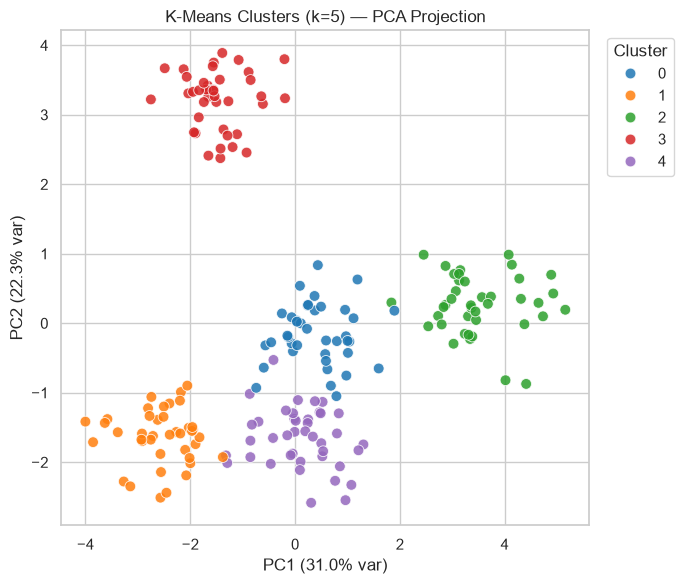

In [7]:
sil = silhouette_score(X_scaled, features_df["cluster_kmeans"])
db = davies_bouldin_score(X_scaled, features_df["cluster_kmeans"])
print(f"Silhouette score: {sil:.3f}")
print(f"Davies-Bouldin index: {db:.3f}  (lower is better)")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)
features_df["pca_1"], features_df["pca_2"] = pca_coords[:, 0], pca_coords[:, 1]

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=features_df, x="pca_1", y="pca_2",
    hue="cluster_kmeans", palette="tab10", s=60, alpha=0.85,
)
plt.title(f"K-Means Clusters (k={N_CLUSTERS}) — PCA Projection")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


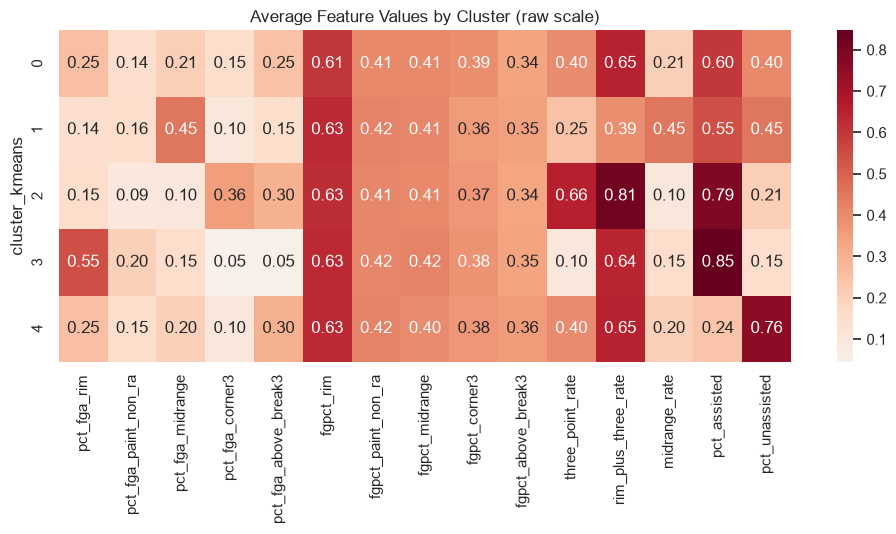

,pct_fga_rim,pct_fga_paint_non_ra,pct_fga_midrange,pct_fga_corner3,pct_fga_above_break3,fgpct_rim,fgpct_paint_non_ra,fgpct_midrange,fgpct_corner3,fgpct_above_break3,three_point_rate,rim_plus_three_rate,midrange_rate,pct_assisted,pct_unassisted
cluster_kmeans,,,,,,,,,,,,,,,
0,0.252455,0.140689,0.208961,0.150359,0.247537,0.608439,0.410172,0.408295,0.391484,0.343563,0.397895,0.650351,0.208961,0.596701,0.403299
1,0.143319,0.157720,0.452347,0.095487,0.151126,0.633093,0.419898,0.413218,0.362758,0.348615,0.246613,0.389932,0.452347,0.546132,0.453868
2,0.152680,0.087186,0.099369,0.357736,0.303028,0.627304,0.412530,0.408522,0.374196,0.336079,0.660765,0.813445,0.099369,0.789726,0.210274
3,0.548525,0.203073,0.151980,0.045292,0.051131,0.629419,0.416968,0.418708,0.380190,0.345251,0.096422,0.644947,0.151980,0.846628,0.153372
4,0.254726,0.147035,0.200590,0.096452,0.301197,0.629124,0.422294,0.398876,0.375960,0.360864,0.397649,0.652375,0.200590,0.244847,0.755153


In [8]:
cluster_profile = features_df.groupby("cluster_kmeans")[FEATURE_COLS].mean()

plt.figure(figsize=(10, 4 + 0.3 * N_CLUSTERS))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Average Feature Values by Cluster (raw scale)")
plt.tight_layout()
plt.show()

cluster_profile


## 9. Comparing Clusters to Known Archetypes

Once real, labeled data (or reasonable manual archetype tags for a subset of well-known players) is available, this section should:

- Cross-tabulate discovered clusters against analyst-assigned archetypes (confusion-matrix style) to see how well they align.
- Spot-check a handful of well-known players per cluster to sanity-check whether the grouping "makes basketball sense."
- Note any surprising groupings (e.g. players who don't fit their expected archetype) as interesting findings rather than errors.

The synthetic data includes a `true_archetype_for_reference_only` column (not used in clustering) purely so this comparison logic can be tested now; drop or replace it once real archetype labels are sourced.


In [9]:
comparison = pd.crosstab(
    features_df["true_archetype_for_reference_only"],
    features_df["cluster_kmeans"],
)
comparison


cluster_kmeans,0,1,2,3,4
true_archetype_for_reference_only,,,,,
balanced_wing,39,0,0,0,1
midrange_scorer,0,40,0,0,0
rim_runner,0,0,0,40,0
shot_creator,0,0,0,0,40
three_and_d,0,0,40,0,0


In [10]:
# Spot-check a few players per cluster
for c in sorted(features_df["cluster_kmeans"].unique()):
    sample = features_df.loc[features_df["cluster_kmeans"] == c, "player_name"].head(5).tolist()
    print(f"Cluster {c}: {sample}")


Cluster 0: ['Player_004', 'Player_009', 'Player_014', 'Player_019', 'Player_024']
Cluster 1: ['Player_003', 'Player_008', 'Player_013', 'Player_018', 'Player_023']
Cluster 2: ['Player_001', 'Player_006', 'Player_011', 'Player_016', 'Player_021']
Cluster 3: ['Player_000', 'Player_005', 'Player_010', 'Player_015', 'Player_020']
Cluster 4: ['Player_002', 'Player_007', 'Player_012', 'Player_017', 'Player_022']


## 10. Limitations & Next Steps

**Documented limitations:**
- **Subjectivity of k.** The number of clusters is a modeling choice guided by elbow/silhouette diagnostics and domain interpretation, not a single "correct" answer — different k values will emphasize coarser or finer-grained archetypes.
- **Team and system context.** A player's shot profile is shaped by their role, offensive scheme, and teammates, not just individual skill or tendency — the same player could look different on a different team.
- **Season-level aggregation.** Aggregating across a season can obscure within-season changes (role changes, injuries, trades).
- **Synthetic placeholder data.** Results in this scaffold are generated from simulated data and are not meant to be interpreted basketball-wise; they exist only to validate the pipeline.
- **Sample size per player.** Very low-volume shooters in certain zones produce noisy efficiency estimates even after the `MIN_FGA` filter.

**Next steps:**
1. Wire in real data via `nba_api` (or an alternate source) in Section 2, matching the existing schema.
2. Revisit `MIN_FGA` and zone definitions against actual data availability.
3. Try alternative clustering algorithms (GMM, hierarchical — already scaffolded) and compare stability/agreement with K-Means.
4. Bring in a real reference archetype labeling (e.g. hand-labeled by basketball knowledge, or sourced from existing public archetype work) for Section 9.
5. Consider adding tracking-data features (touch time, dribbles per touch, contested rate) if available, to enrich beyond pure shot-location data.
